# Memprediksi Kegagalan Jantung: Analisis Model Naïve Bayes untuk Deteksi Risiko Kematian

#### 1. Import Libraries

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

#### 2. Import Data

In [22]:
data = pd.read_csv("/Users/Apple/Documents/Project Data Science/Project Python/Naive Bayes/heart_failure_clinical_records_dataset.csv")

#### 3. Data Preprocessing

In [24]:
data.head(20)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


Berikut adalah dataset yang telah diimport. Dataset tersebut berisi catatan medis dari pasien yang mengalami gagal jantung. Fitur dalam dataset ini yaitu :

Fitur dalam Dataset:
1. age: Usia pasien (tahun).
2. anaemia: Kondisi penurunan jumlah sel darah merah atau hemoglobin (boolean).
3. creatinine_phosphokinase: Tingkat enzim CPK dalam darah (mcg/L).
4. diabetes: Apakah pasien menderita diabetes (boolean).
5. ejection_fraction: Persentase darah yang keluar dari jantung pada setiap kontraksi (%).
6. high_blood_pressure: Apakah pasien menderita hipertensi (boolean).
7. platelets: Jumlah trombosit dalam darah (kiloplatelets/mL).
8. serum_creatinine: Tingkat kreatinin serum dalam darah (mg/dL).
9. serum_sodium: Tingkat natrium serum dalam darah (mEq/L).
10. sex: Jenis kelamin pasien (binary: 0 = perempuan, 1 = laki-laki).
11. smoking: Apakah pasien merokok (boolean).
12. time: Lama periode tindak lanjut (hari).
13. DEATH_EVENT: Apakah pasien meninggal selama periode tindak lanjut (boolean).

Disini, ada nama kolom yang ingin saya ubah, yakni adanya typo pada kolom 'anaemia' yang seharusnya 'anemia'.

In [37]:
data = data.rename(columns={'anaemia':'anemia'})

In [28]:
data.head()

,age,anemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [40]:
data.isna().sum()

age                         0
anemia                      0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

Terlihat data tidak memiliki missing value

- Deskripsi dan Distribusi Data

In [42]:
data.describe()

,age,anemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


<Axes: xlabel='age', ylabel='Count'>

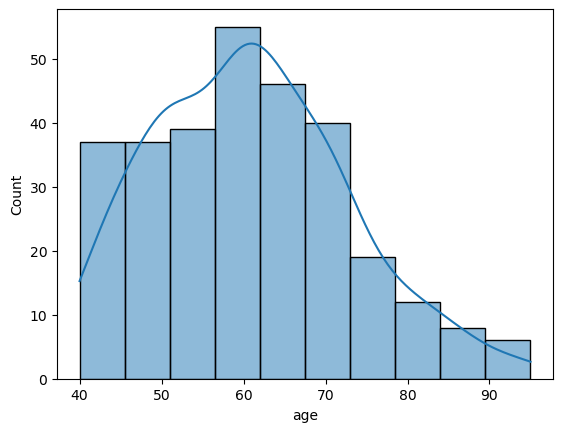

In [50]:
sns.histplot(data['age'], kde = True)

<Axes: xlabel='platelets', ylabel='Count'>

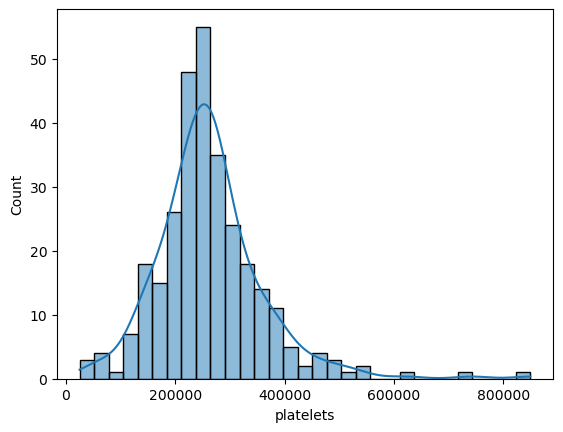

In [53]:
sns.histplot(data['platelets'], kde = True)

Berikut adalah deskripsi dari data tersebut. Dimana, kita bisa melihat adanya sebaran dari tiap fitur pada data. Disini, saya mendapatkan beberapa informasi yang penting, yakni rentang umur pasien sekitar 40 - 95 tahun, dan rata-rata umur pasien di 60 tahun. Lalu, jumlah trombosit pada darah pasien beriksar di rentang 25100 - 850000 (kiloplatelets/Ml), dan rata-rata sebesar 263358

- Correlation Matrix

In [57]:
data.corr()

,age,anemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,-0.224068,0.253729
anemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,0.010514,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,-0.149315,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.015608,-0.004316


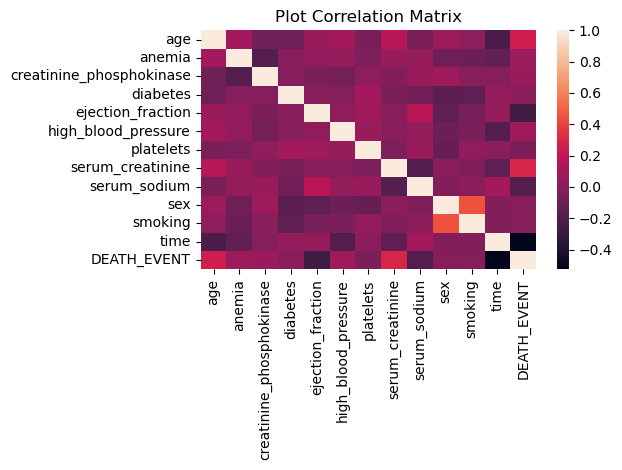

In [89]:
plt.figure()
sns.heatmap(data.corr())
plt.title('Plot Correlation Matrix')
plt.tight_layout()
plt.show()

Berikut adalah korelasi matrix dari data. Saya mendapatkan bahwa variabel age, time, dan ejection_fraction merupakan beberapa variabel yang memiliki korelasi cukup kuat dengan variabel DEATH_EVENT (yakni masing-masing sebesar 0.253729, -0.526964, -0.268603) Sehingga, saya akan menggunakan variabel ini sebagai variabel independen untuk model saya. Saya akan menggunakan Age dan ejection_fraction sebagai X

#### Membangun Model

- Split Data

In [159]:
#Menntukan variable independen dan dependen
X = data[['age','ejection_fraction']].values
y = data.iloc[:, -1].values

- Membagi menjadi test dan train

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = True)

- Feature Scaling

In [163]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

- Train Model

In [165]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

- Prediksi

In [167]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape( len (y_pred), 1), y_test.reshape( len (y_test),1)),1))

[[0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 0]]


Setelah model berhasil dibuat, selanjutnya melakukan evaluasi

- Akurasi Model

In [169]:
accuracy_score(y_test, y_pred)

0.8133333333333334

In [171]:
#F1 Score
print(f"F score: {f1_score(y_test, y_pred)}")

F score: 0.5333333333333333


In [173]:
# Classification report
print(f'Classification Report: \n{classification_report(y_test, y_pred)}')

Classification Report: 
              precision    recall  f1-score   support

           0       0.82      0.96      0.88        55
           1       0.80      0.40      0.53        20

    accuracy                           0.81        75
   macro avg       0.81      0.68      0.71        75
weighted avg       0.81      0.81      0.79        75



<Axes: >

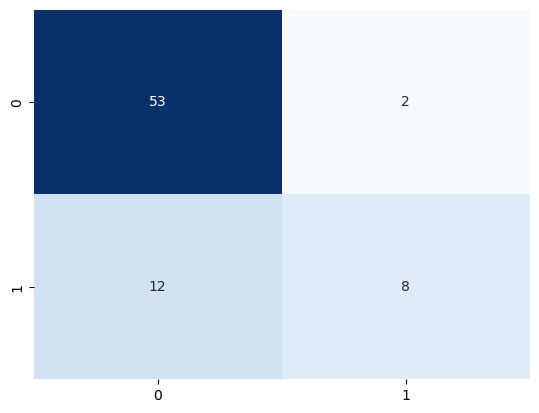

In [175]:
#Confussion Matrix
cfmatrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cfmatrix, annot= True, fmt="d", cmap="Blues", cbar=False)

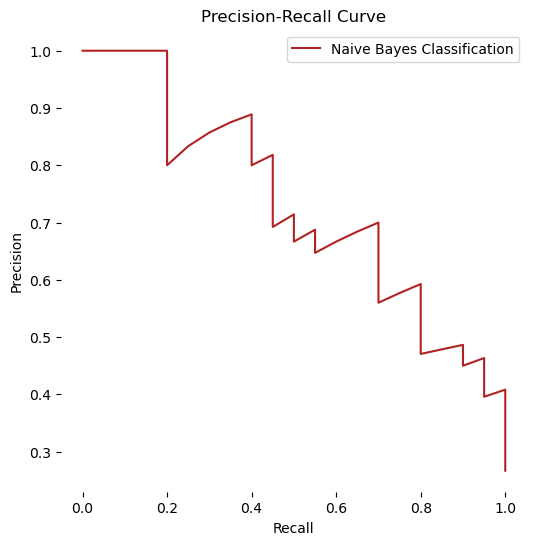

In [179]:
# Plot Precision-Recall Curve
y_pred_proba = classifier.predict_proba(X_test) [:,1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize = (6,6))
ax.plot(recall, precision, label='Naive Bayes Classification', color = 'firebrick')
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.box (False)
ax.legend();

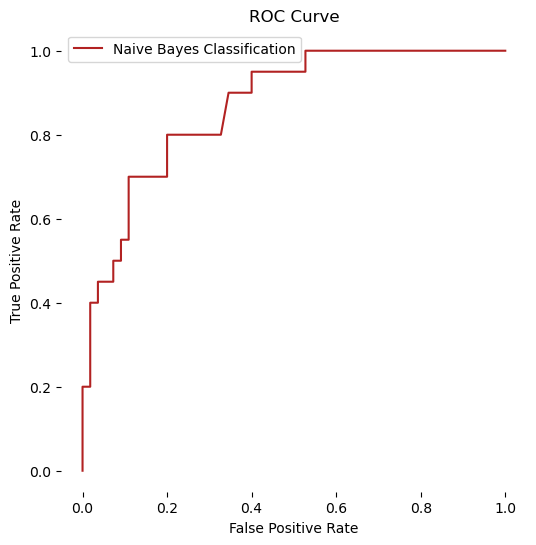

In [181]:
# Plot ROC
y_pred_proba = classifier.predict_proba(X_test) [:,1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr, tpr, label='Naive Bayes Classification', color = 'firebrick')
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.box(False)
ax.legend();

- Visualisasi Hasil

/var/folders/43/fqh9vxfs3tbfzc60n7zwz2v00000gn/T/ipykernel_2462/776672633.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set==j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


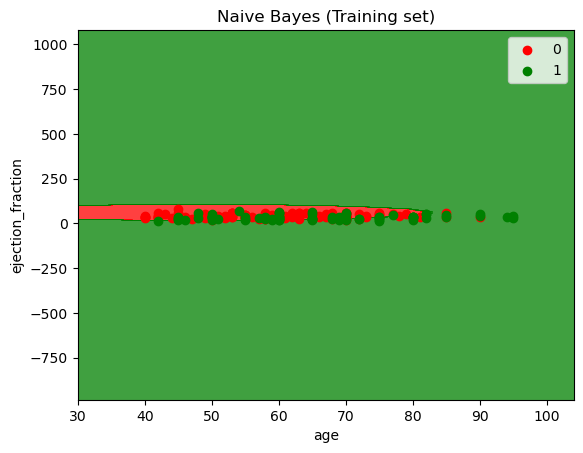

In [185]:
    X_set, y_set = sc.inverse_transform(X_train), y_train
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                         np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
    plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
                 alpha=0.75, cmap=ListedColormap(('red', 'green')))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate (np.unique(y_set)):
      plt.scatter(X_set[y_set == j, 0], X_set[y_set==j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
    plt.title('Naive Bayes (Training set)')
    plt.xlabel('age')
    plt.ylabel('ejection_fraction')
    plt.legend()
    plt.show()

/var/folders/43/fqh9vxfs3tbfzc60n7zwz2v00000gn/T/ipykernel_2462/344848209.py:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set==j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


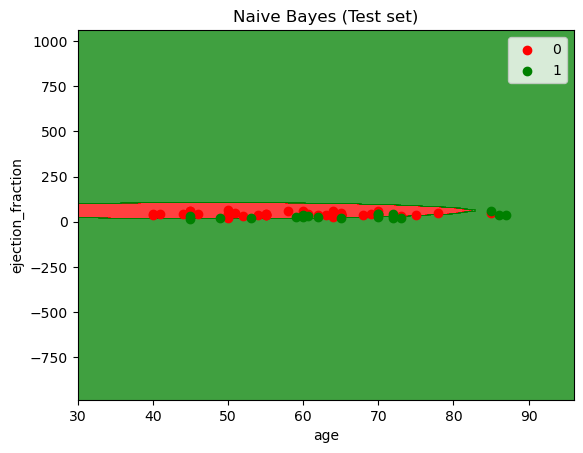

In [187]:
# Visualize prediction results on test set

X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate (np.unique(y_set)):
  plt.scatter(X_set[y_set == j, 0], X_set[y_set==j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('age')
plt.ylabel('ejection_fraction')
plt.legend()
plt.show()

In [258]:
#prediksi pasien 1 dengan umur (64) dan ejection_fraction(80%)
print(classifier.predict(sc.transform([[63, 80]])))

[0]


In [260]:
#prediksi pasien 2 dengan umur (80) dan ejection_fraction(70%)
print(classifier.predict(sc.transform([[80, 70]])))

[0]


In [262]:
#prediksi pasien 3 dengan umur (80) dan ejection_fraction(40%)
print(classifier.predict(sc.transform([[80, 40]])))

[1]


Hasil yang didapatkan adalah sebagai berikut:
Dilakukan 3 kali prediksi dengan model Naive Bayes, dan dengan perbedaan profil pasien.
Perlu diketahui juga mengenai ejection_fraction (fraksi ejeksi) jantung adalah sebagai berikut:

< 40 % = Mengindikasikan fungsi jalan jantung terganggu
40% - 50% = Mengindikasikan adanya gangguan pada jantung
55% - 70% = Normal
70% - 100% = Berjalan dengan sangat baik

Pasien 1
Umur: 63 Tahun
Fraksi Ejeksi: 80%
Interpretasi Fraksi Ejeksi: 80% menunjukkan fungsi jantung yang sangat baik.
Prediksi: 0 (tidak meninggal)
Analisis: Dengan umur 63 tahun dan fraksi ejeksi yang sangat baik, prediksi bahwa pasien tidak meninggal pada periode tindak lanjut tampaknya konsisten dengan kondisi jantung yang sehat.

Pasien 2
Umur: 80 Tahun
Fraksi Ejeksi: 70%
Interpretasi Fraksi Ejeksi: 70% berada pada batas atas rentang normal, menunjukkan fungsi jantung yang sangat baik.
Prediksi: 0 (tidak meninggal)
Analisis: Meskipun pasien berusia 80 tahun, fraksi ejeksi yang berada pada rentang normal atas mendukung prediksi bahwa pasien tidak akan meninggal pada periode tindak lanjut. Usia yang lebih tua mungkin meningkatkan risiko, tetapi kondisi jantung yang baik berkontribusi pada prediksi yang positif.

Pasien 3
Umur: 80 Tahun
Fraksi Ejeksi: 40%
Interpretasi Fraksi Ejeksi: 40% menunjukkan adanya gangguan pada fungsi jantung.
Prediksi: 1 (meninggal)
Analisis: Ejection fraction yang rendah (40%) menunjukkan adanya masalah signifikan dengan fungsi jantung, dan prediksi bahwa pasien meninggal pada periode tindak lanjut sesuai dengan kondisi jantung yang buruk. Usia yang lebih tua juga dapat meningkatkan risiko kematian.

Kesimpulan dan Saran :
Konsistensi dengan Fraksi Ejeksi: Prediksi dari model Naive Bayes tampak konsisten dengan fraksi ejeksi yang diberikan. Model memprediksi dengan lebih akurat pada pasien dengan fraksi ejeksi yang ekstrem (baik sangat baik atau sangat rendah).

- Pengaruh Umur: Meskipun umur merupakan faktor penting dalam risiko kematian, fraksi ejeksi tampaknya memiliki dampak yang lebih besar dalam model Anda. Ini sesuai dengan fakta bahwa kondisi jantung yang buruk sering lebih berpengaruh daripada umur itu sendiri.

Model dan Validasi:

- Validasi Lebih Lanjut: Penting untuk memvalidasi model dengan lebih banyak data untuk memastikan bahwa prediksi tetap akurat di berbagai kondisi.

- Faktor Lain: Pertimbangkan untuk memasukkan faktor tambahan (misalnya, riwayat penyakit, gaya hidup) dalam model untuk meningkatkan akurasi prediksi.

- Evaluasi Klinis: Selalu konsultasikan hasil model dengan profesional medis untuk interpretasi yang lebih komprehensif dan penanganan kasus klinis.

- Naive Bayes: Model Naive Bayes Anda memberikan prediksi yang bermanfaat, namun harus diperhatikan bahwa Naive Bayes mengasumsikan independensi antara fitur, yang mungkin tidak sepenuhnya berlaku dalam konteks kesehatan. Pertimbangkan untuk mengeksplorasi model lain atau teknik pemrosesan fitur untuk meningkatkan hasil prediksi.